In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
# Ver las primeras líneas crudas del archivo
with open("simulaciones/fs=1000Hz/WF+noise/WF_W1R_L020_fase000_noise_RECTA_ERRI_High_VEL020_fs1000.csv") as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 2:
            break

'"time";"result.$G_Acelerometros.$RS_Acc_AxleBox_1R.Acceleration in z";"result.$G_Acelerometros.$RS_Acc_AxleBox_1L.Acceleration in z";"result.$G_Acelerometros.$RS_Acc_AxleBox_2R.Acceleration in z";"result.$G_Acelerometros.$RS_Acc_AxleBox_2L.Acceleration in z";"result.$G_Acelerometros.$RS_Acc_AxleBox_3R.Acceleration in z";"result.$G_Acelerometros.$RS_Acc_AxleBox_3L.Acceleration in z";"result.$G_Acelerometros.$RS_Acc_AxleBox_4R.Acceleration in z";"result.$G_Acelerometros.$RS_Acc_AxleBox_4L.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_F_RF.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_F_LF.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_F_RB.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_F_LB.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_R_1R.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_R_1L.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_R_2R.Acceleration in z";"result.$G_Acelerometros.$RS_ACC_Bogie_R_2L.Acc

In [3]:
df = pd.read_csv(
    "simulaciones/fs=1000Hz/WF+noise/WF_W1R_L020_fase000_noise_RECTA_ERRI_High_VEL020_fs1000.csv",
    sep=';',
    skiprows=[1],      # salta la fila de unidades
    quotechar='"'      # maneja las comillas en el header
)

# Renombrar columnas a nombres cortos
col_names = ['t', 
             'az_AB_1R', 'az_AB_1L', 'az_AB_2R', 'az_AB_2L',
             'az_AB_3R', 'az_AB_3L', 'az_AB_4R', 'az_AB_4L',
             'az_BG_F_RF', 'az_BG_F_LF', 'az_BG_F_RB', 'az_BG_F_LB',
             'az_BG_R_RF', 'az_BG_R_LF', 'az_BG_R_RB', 'az_BG_R_LB',
             'az_Plat_F', 'az_Plat_R',
             'vel']
df.columns = col_names

print(df.shape)
print(df.head())

(9001, 20)
        t  az_AB_1R  az_AB_1L  az_AB_2R  az_AB_2L  az_AB_3R  az_AB_3L  \
0  23.670 -9.809999 -9.809999     -9.81     -9.81     -9.81     -9.81   
1  23.671 -9.809999 -9.809999     -9.81     -9.81     -9.81     -9.81   
2  23.672 -9.809999 -9.809999     -9.81     -9.81     -9.81     -9.81   
3  23.673 -9.809999 -9.809999     -9.81     -9.81     -9.81     -9.81   
4  23.674 -9.809999 -9.809999     -9.81     -9.81     -9.81     -9.81   

   az_AB_4R  az_AB_4L  az_BG_F_RF  az_BG_F_LF  az_BG_F_RB  az_BG_F_LB  \
0     -9.81     -9.81   -9.809999       -9.81   -9.809999       -9.81   
1     -9.81     -9.81   -9.809999       -9.81   -9.809999       -9.81   
2     -9.81     -9.81   -9.809999       -9.81   -9.809999       -9.81   
3     -9.81     -9.81   -9.809999       -9.81   -9.809999       -9.81   
4     -9.81     -9.81   -9.809999       -9.81   -9.809999       -9.81   

   az_BG_R_RF  az_BG_R_LF  az_BG_R_RB  az_BG_R_LB  az_Plat_F  az_Plat_R  \
0       -9.81       -9.81       -9.8

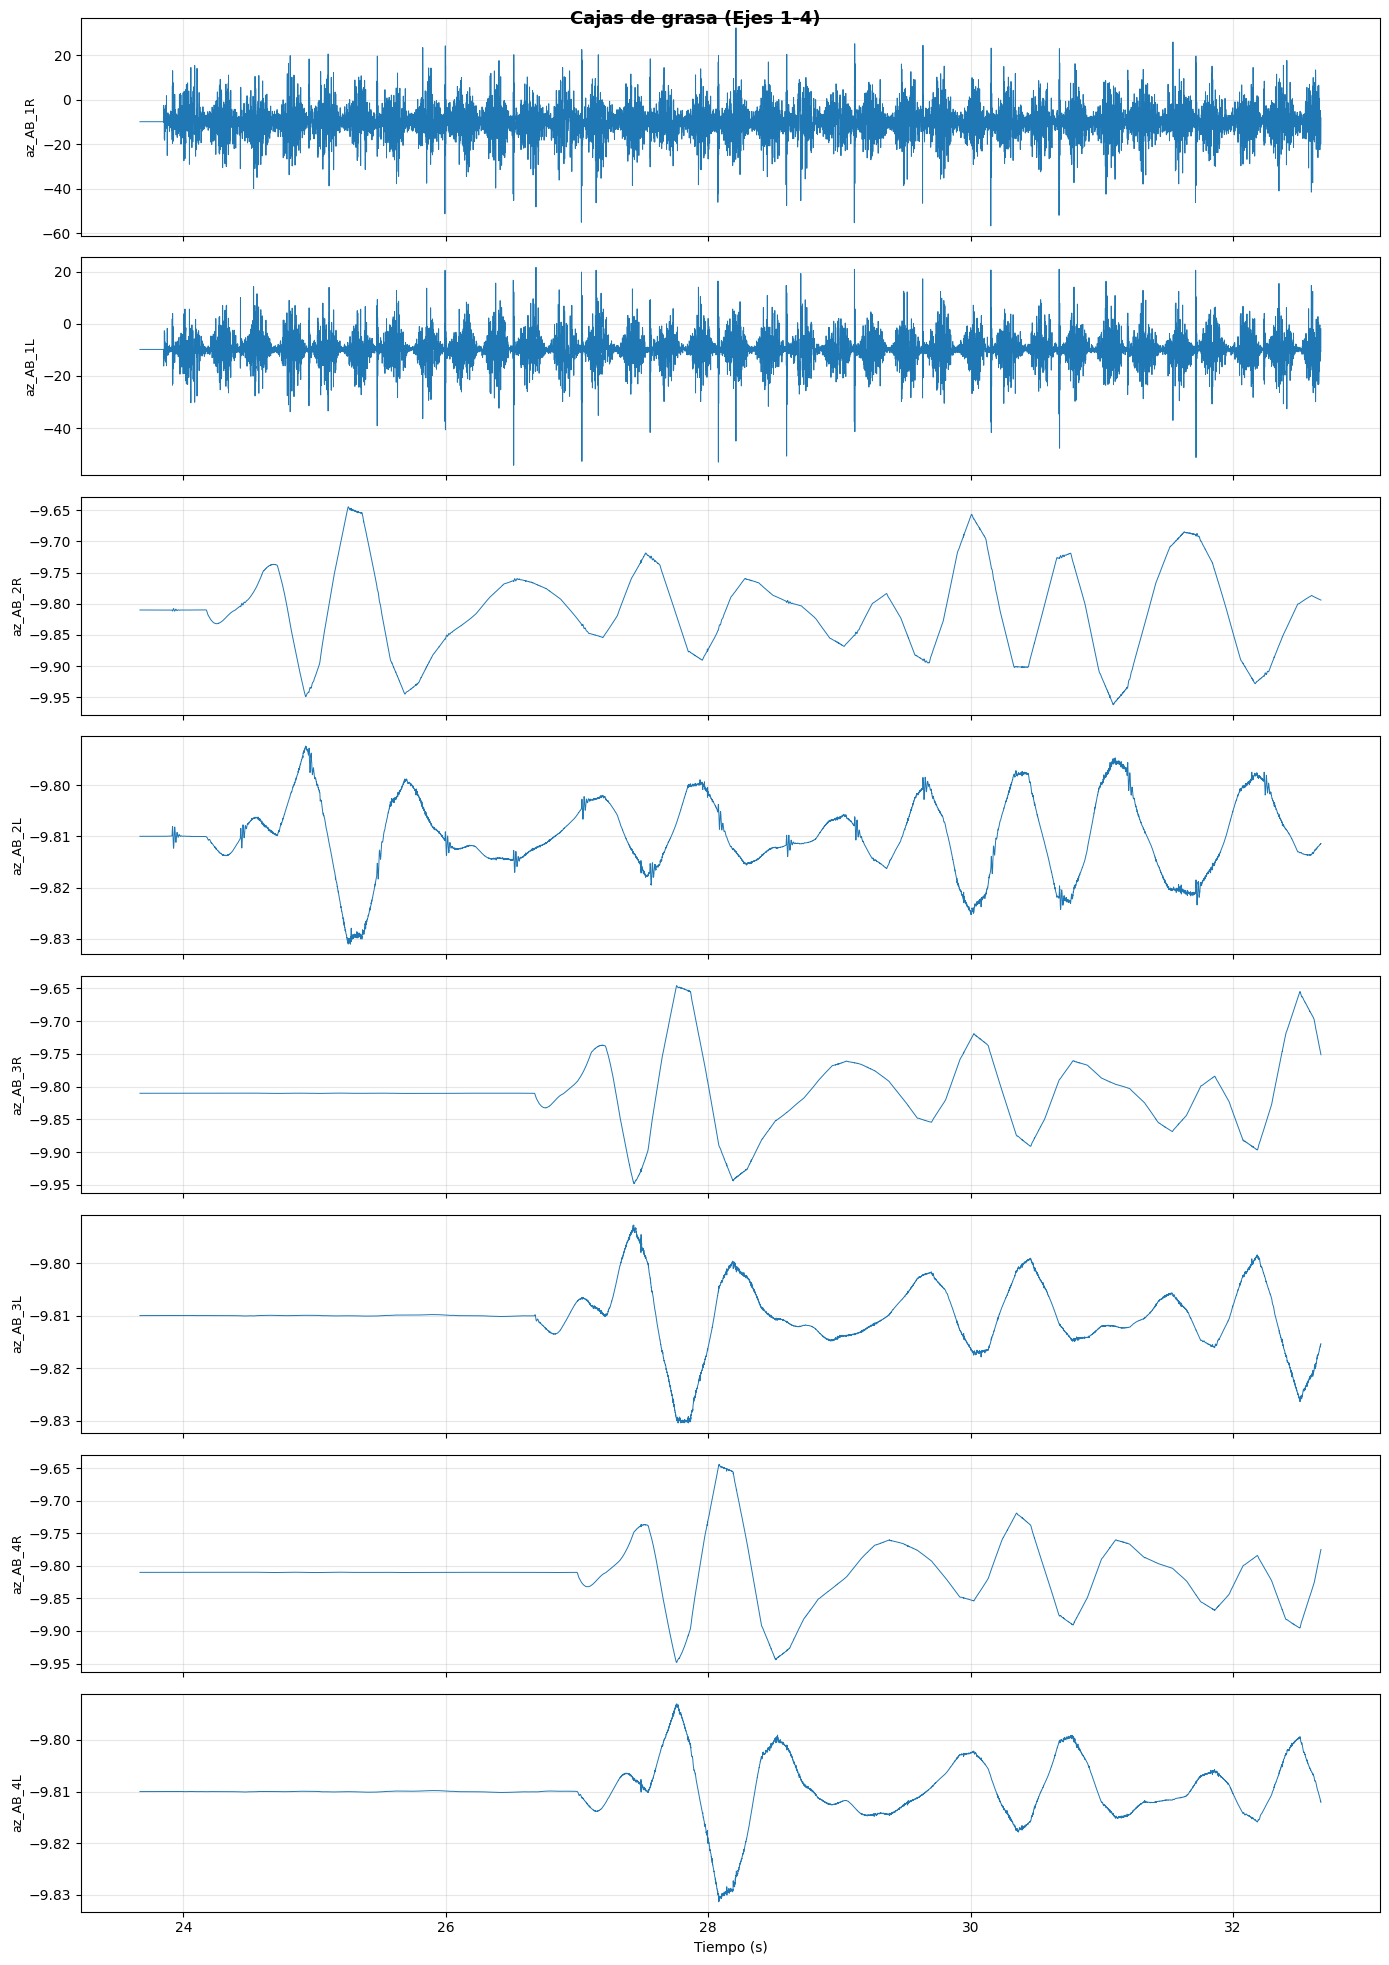

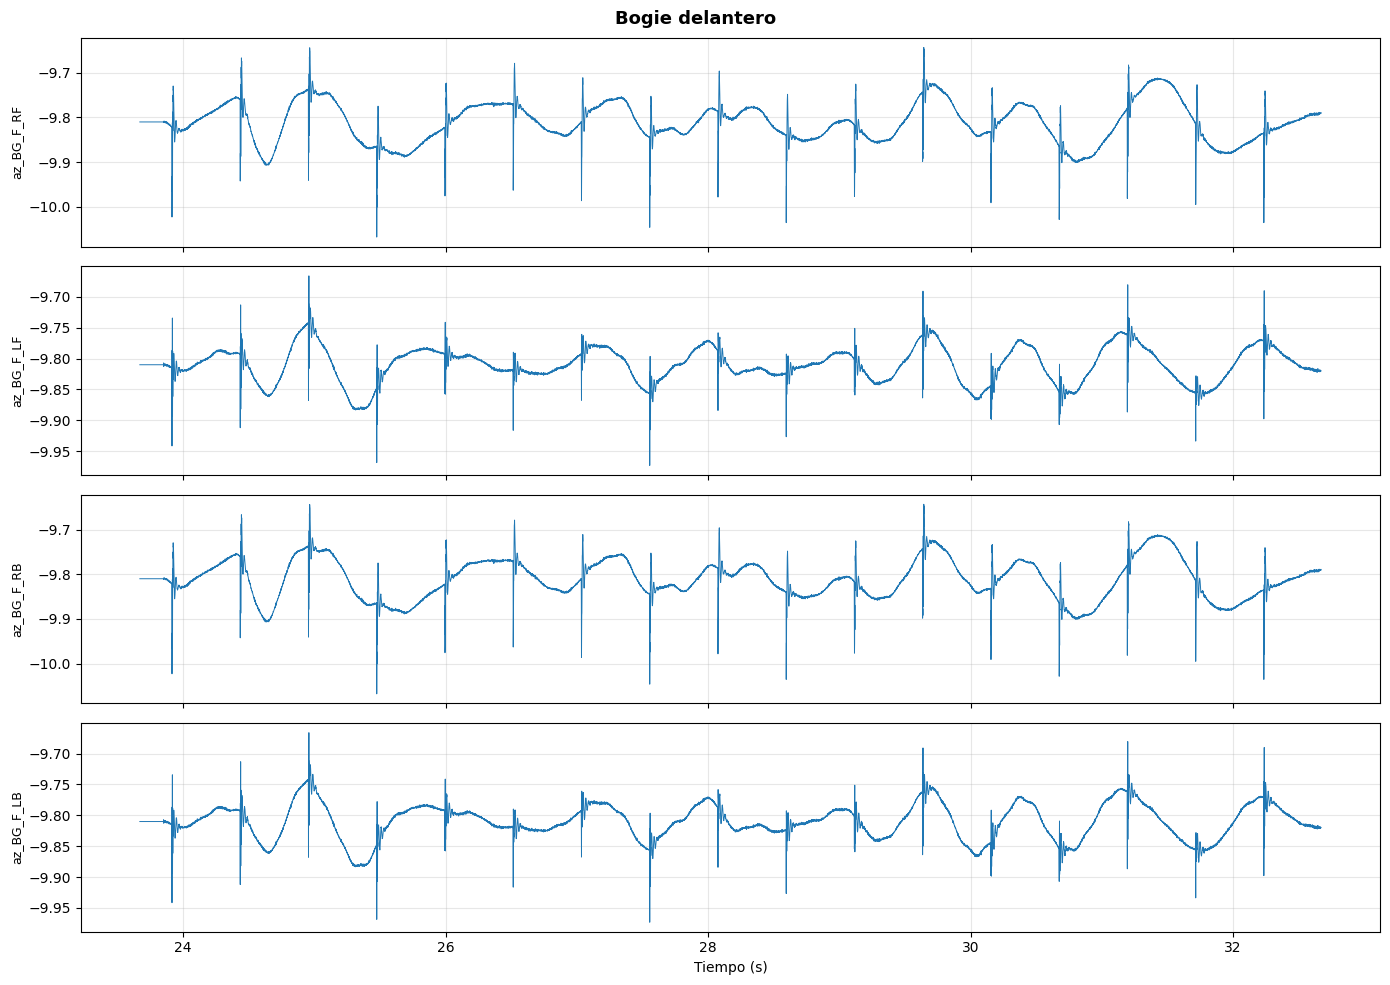

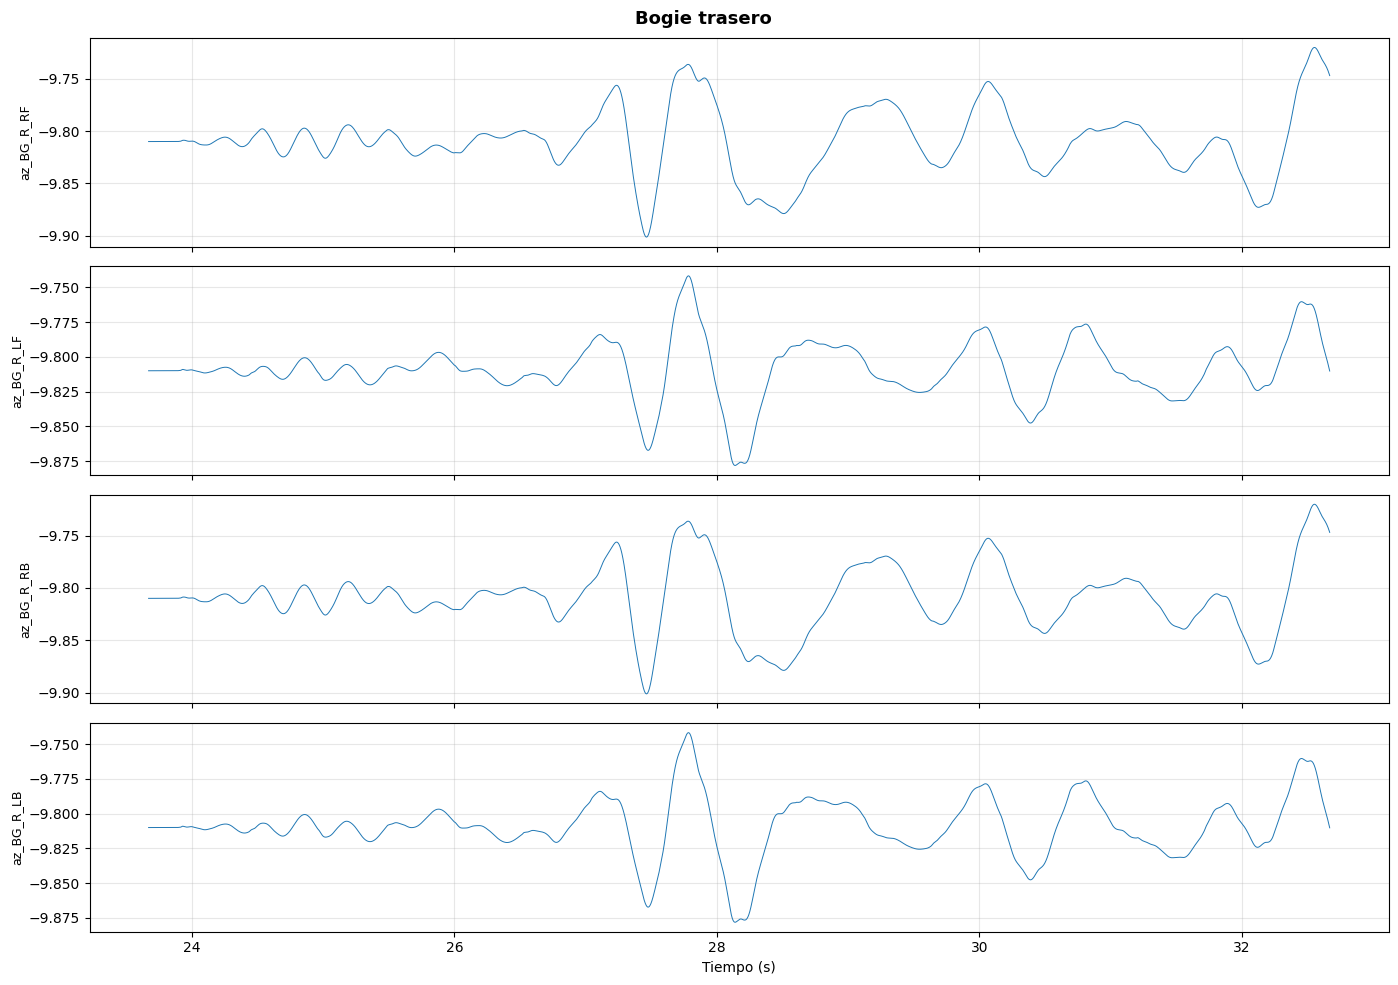

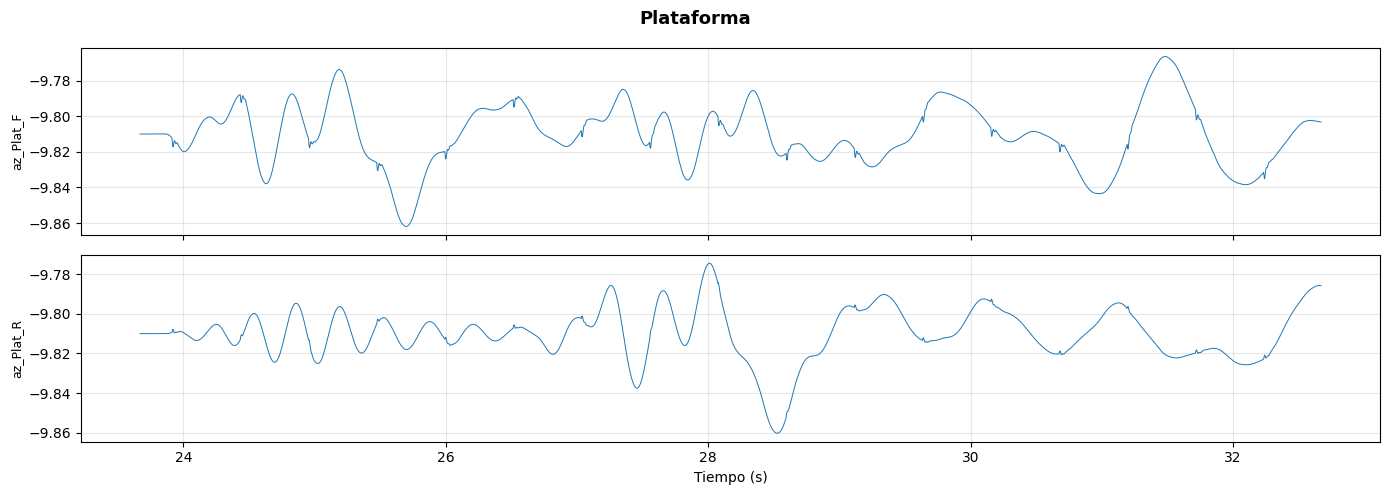

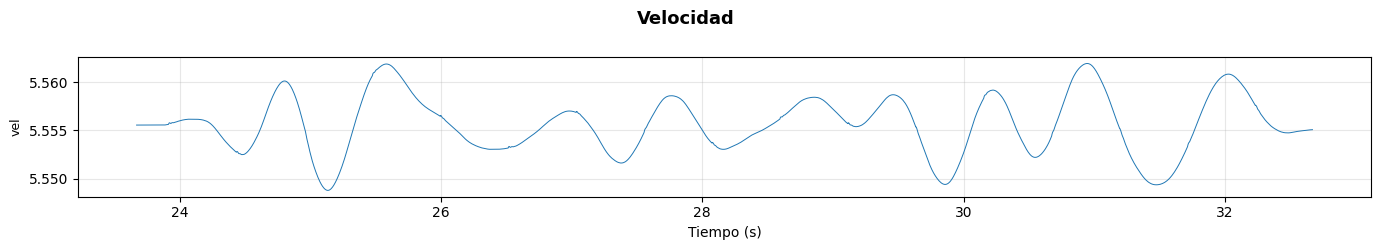

In [4]:
t = df['t']

grupos = {
    "Cajas de grasa (Ejes 1-4)": ['az_AB_1R', 'az_AB_1L', 'az_AB_2R', 'az_AB_2L',
                                   'az_AB_3R', 'az_AB_3L', 'az_AB_4R', 'az_AB_4L'],
    "Bogie delantero": ['az_BG_F_RF', 'az_BG_F_LF', 'az_BG_F_RB', 'az_BG_F_LB'],
    "Bogie trasero":   ['az_BG_R_RF', 'az_BG_R_LF', 'az_BG_R_RB', 'az_BG_R_LB'],
    "Plataforma":      ['az_Plat_F', 'az_Plat_R'],
    "Velocidad":       ['vel'],
}

for nombre_grupo, columnas in grupos.items():
    n = len(columnas)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=True)
    fig.suptitle(nombre_grupo, fontsize=13, fontweight='bold')
    
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, columnas):
        ax.plot(t, df[col], linewidth=0.7)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel("Tiempo (s)")
    plt.tight_layout()
    plt.show()

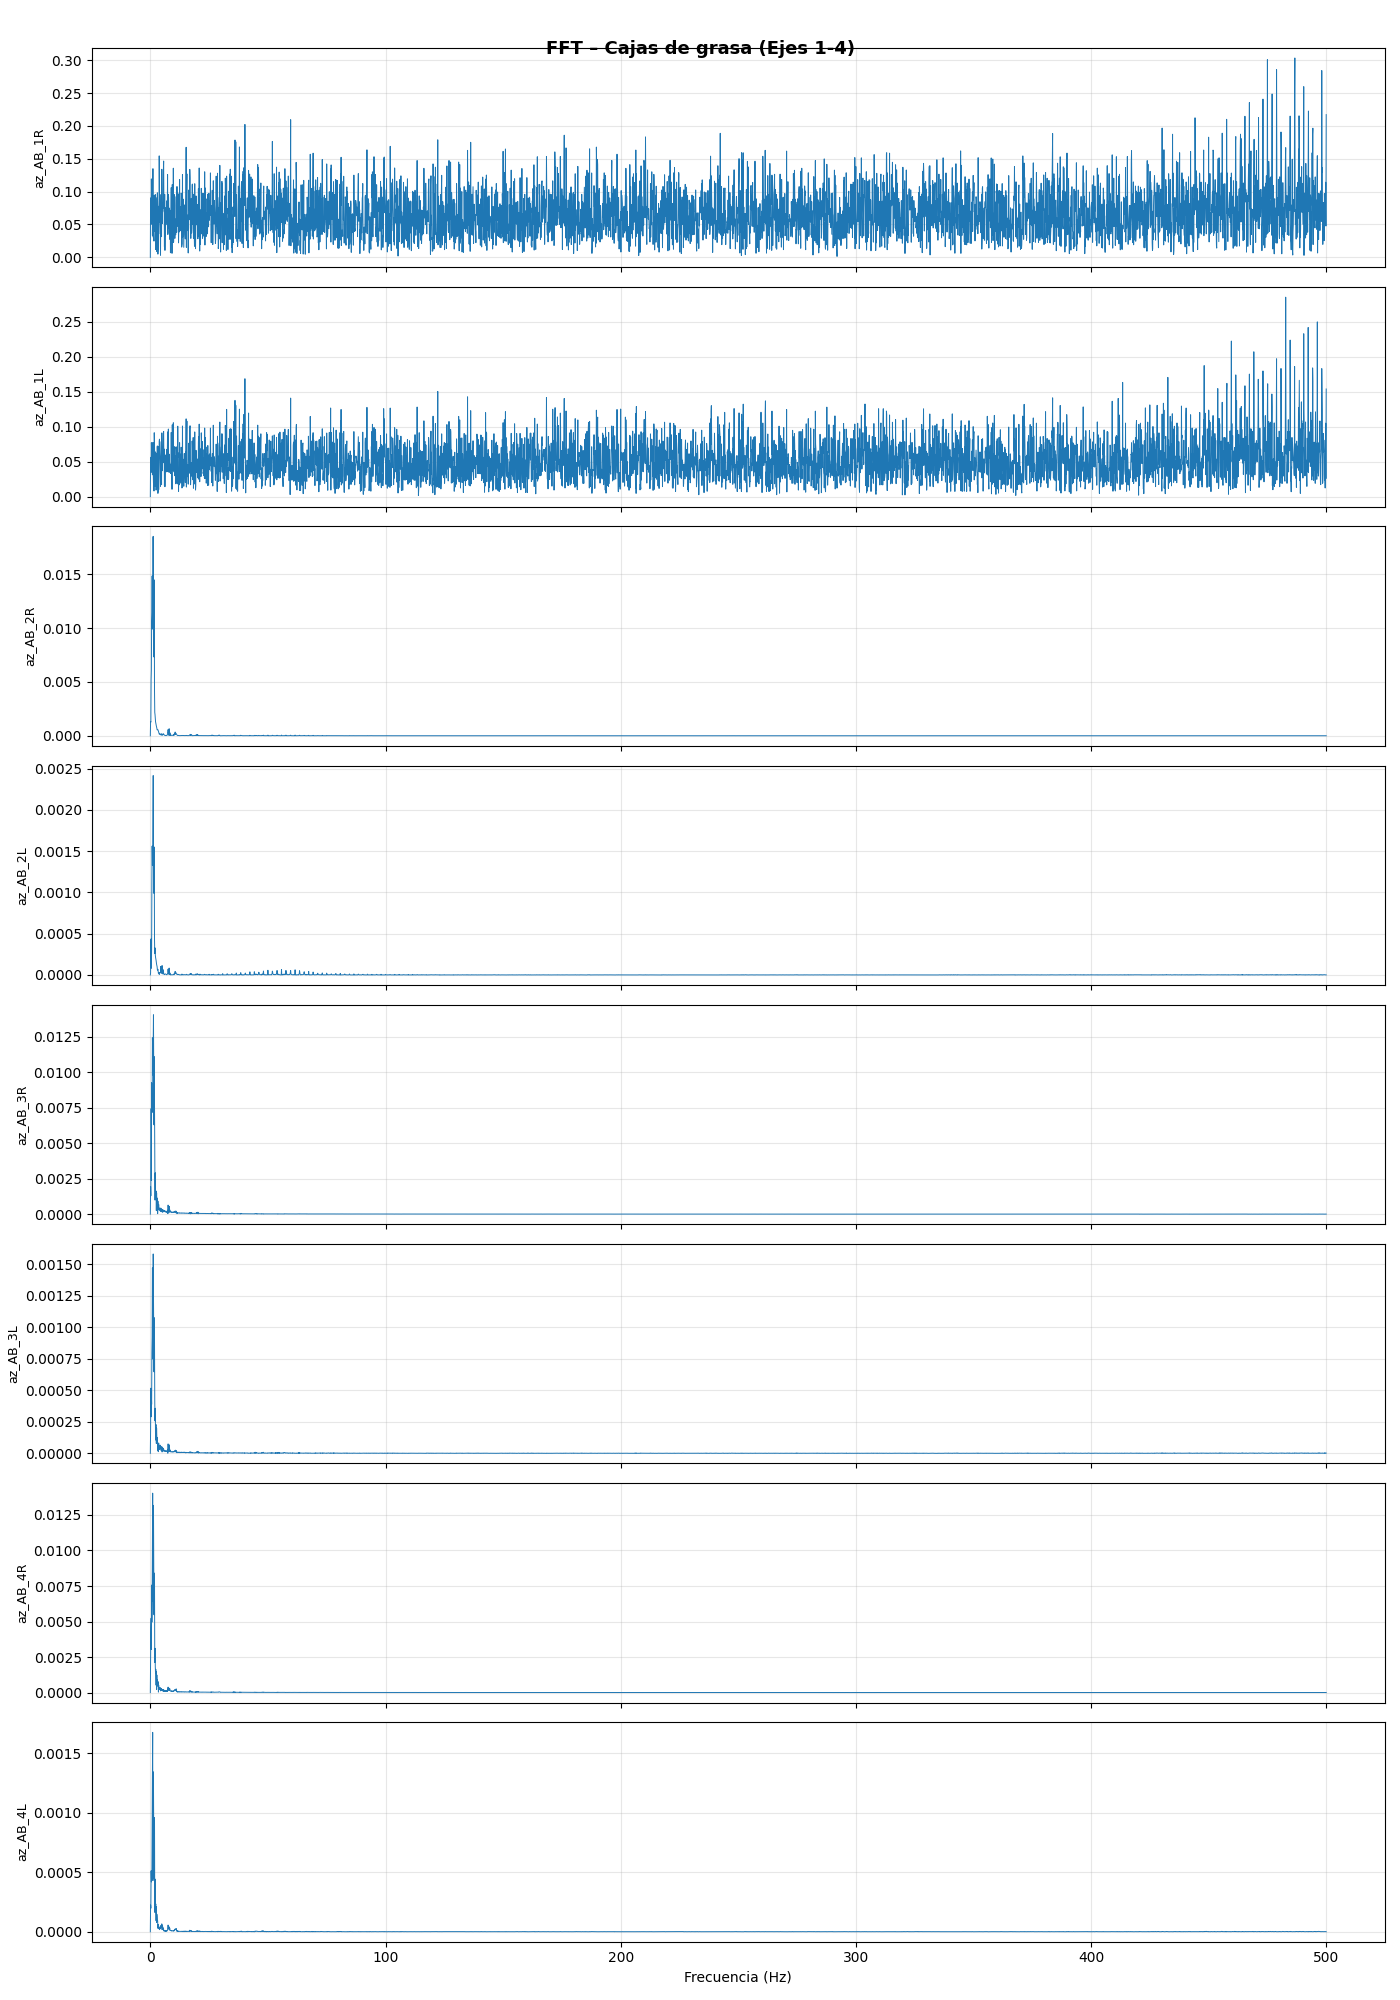

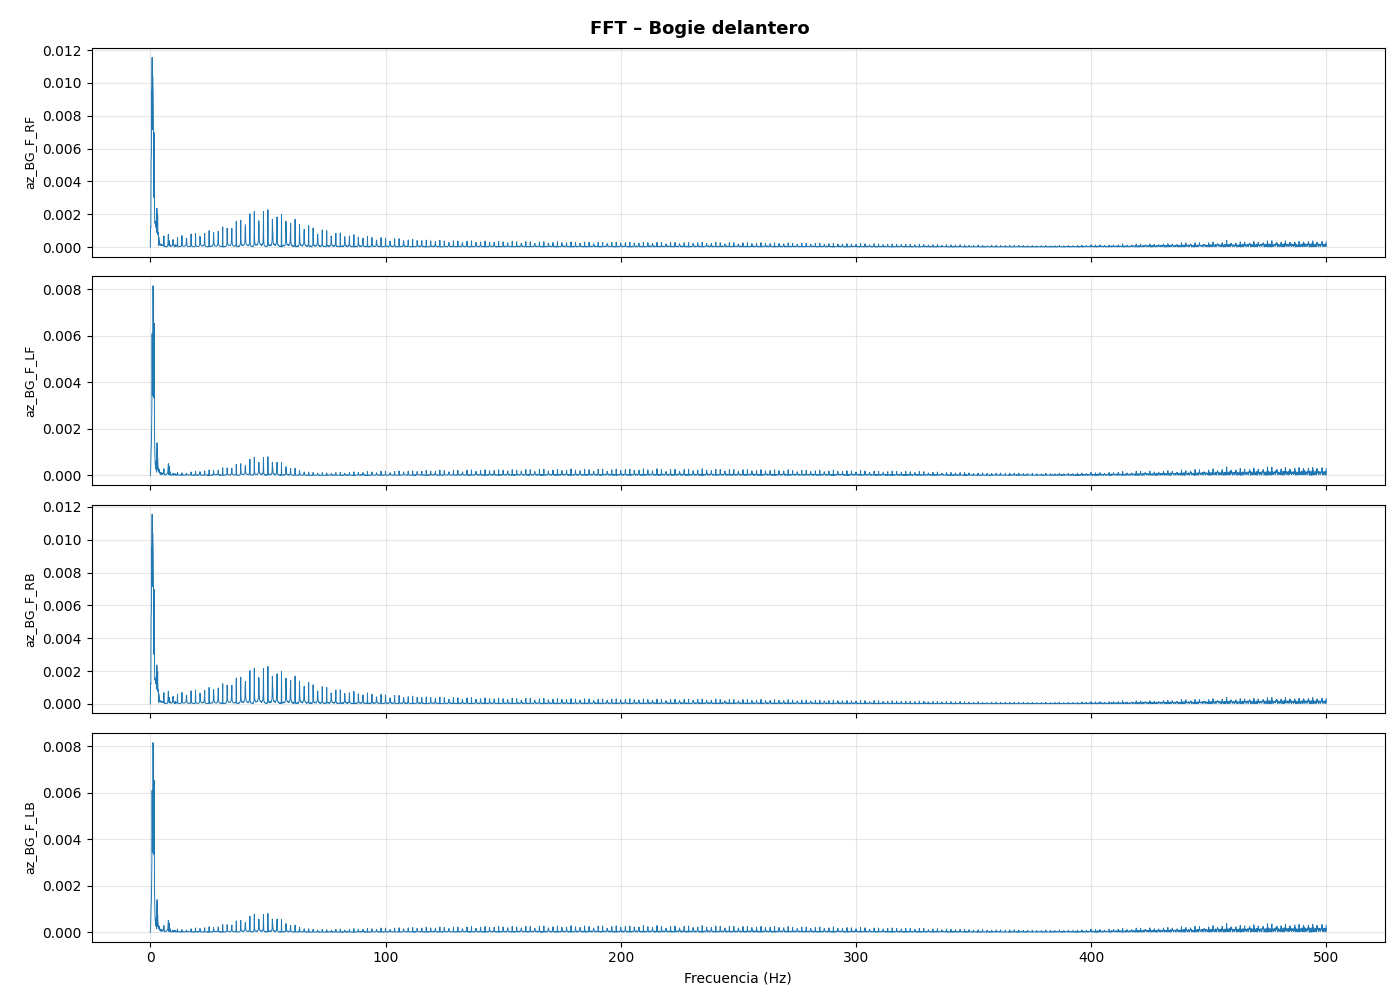

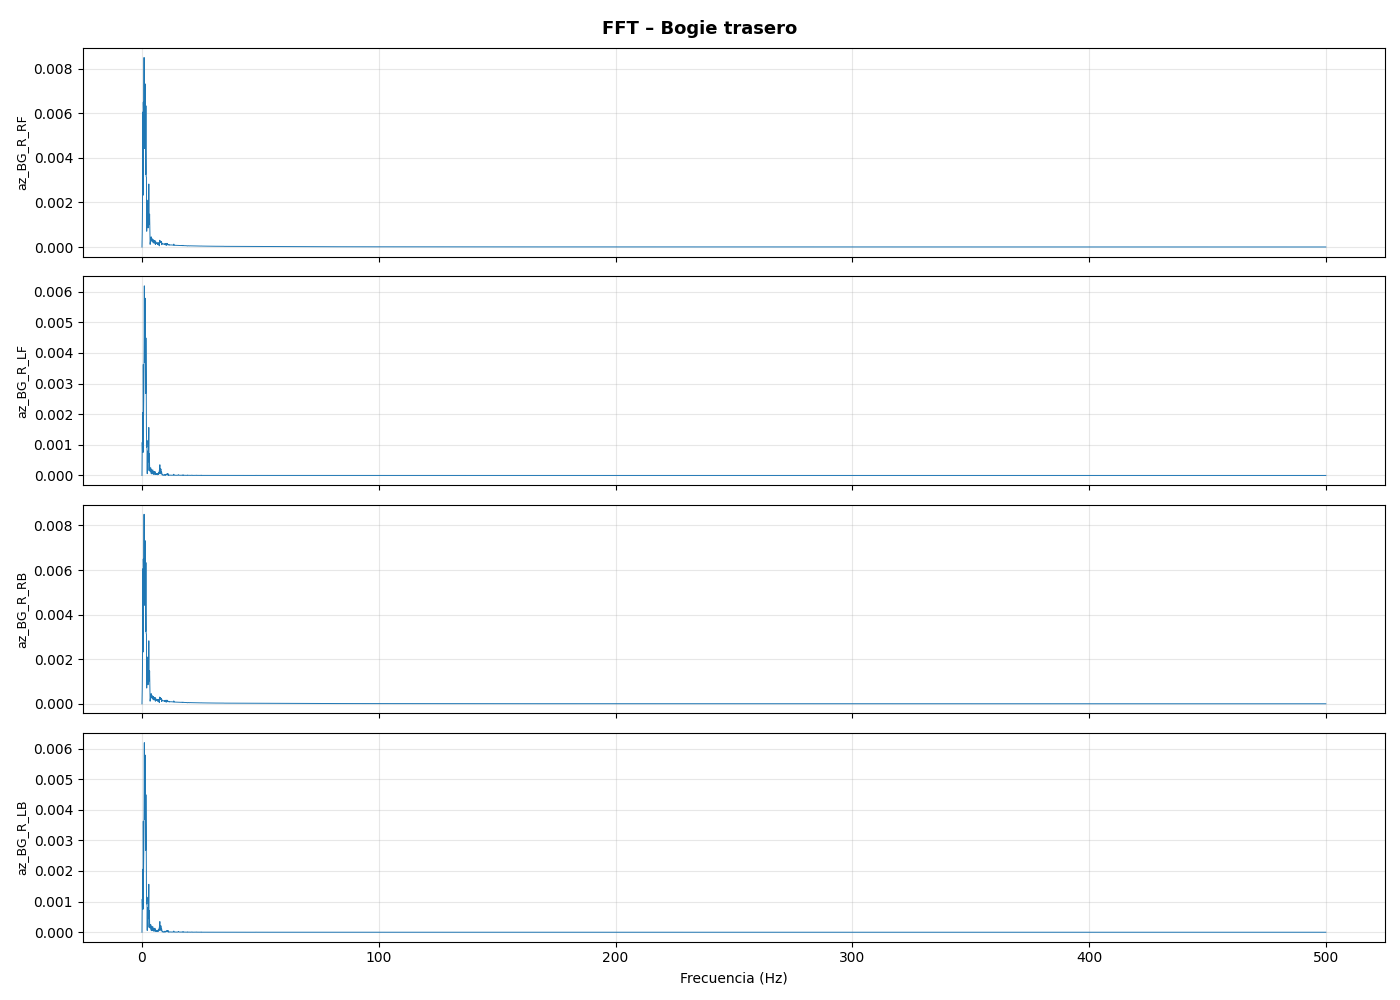

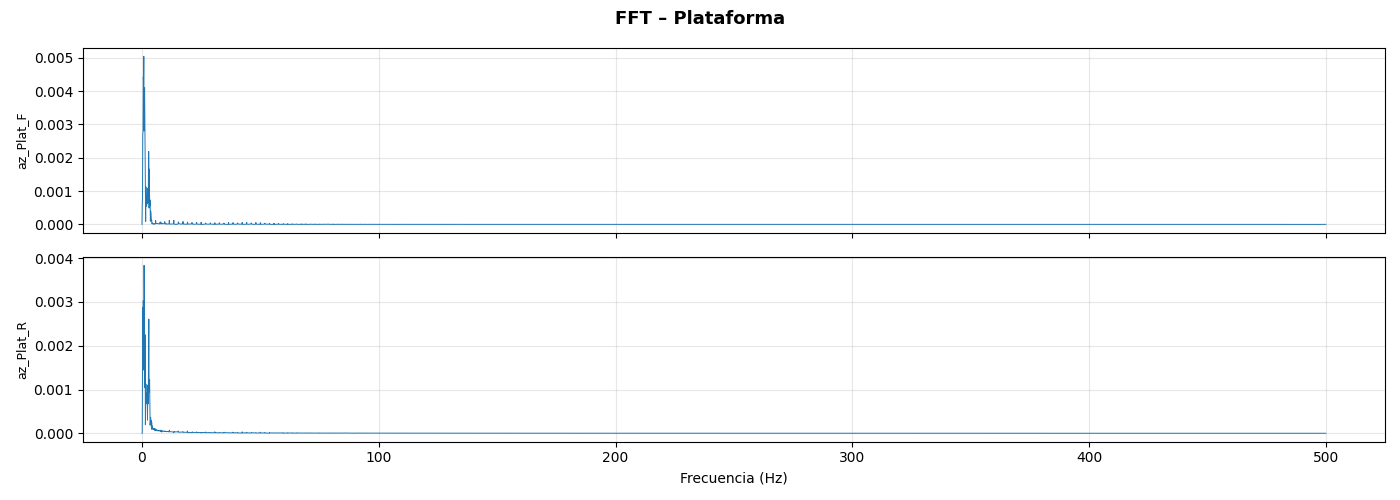

In [9]:
grupos = {
    "Cajas de grasa (Ejes 1-4)": ['az_AB_1R', 'az_AB_1L', 'az_AB_2R', 'az_AB_2L',
                                   'az_AB_3R', 'az_AB_3L', 'az_AB_4R', 'az_AB_4L'],
    "Bogie delantero": ['az_BG_F_RF', 'az_BG_F_LF', 'az_BG_F_RB', 'az_BG_F_LB'],
    "Bogie trasero":   ['az_BG_R_RF', 'az_BG_R_LF', 'az_BG_R_RB', 'az_BG_R_LB'],
    "Plataforma":      ['az_Plat_F', 'az_Plat_R'],
}

fs = 1000  # Hz
N = len(df)
freqs = np.fft.rfftfreq(N, d=1/fs)

for nombre_grupo, columnas in grupos.items():
    n = len(columnas)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=True)
    fig.suptitle(f"FFT – {nombre_grupo}", fontsize=13, fontweight='bold')
    
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, columnas):
        señal = df[col] - df[col].mean()  # quitar media
        fft_mag = np.abs(np.fft.rfft(señal)) / N
        ax.plot(freqs, fft_mag, linewidth=0.7)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel("Frecuencia (Hz)")
    plt.tight_layout()
    plt.show()

In [7]:
%matplotlib widget

[17] az_Plat_R  →  Plataforma


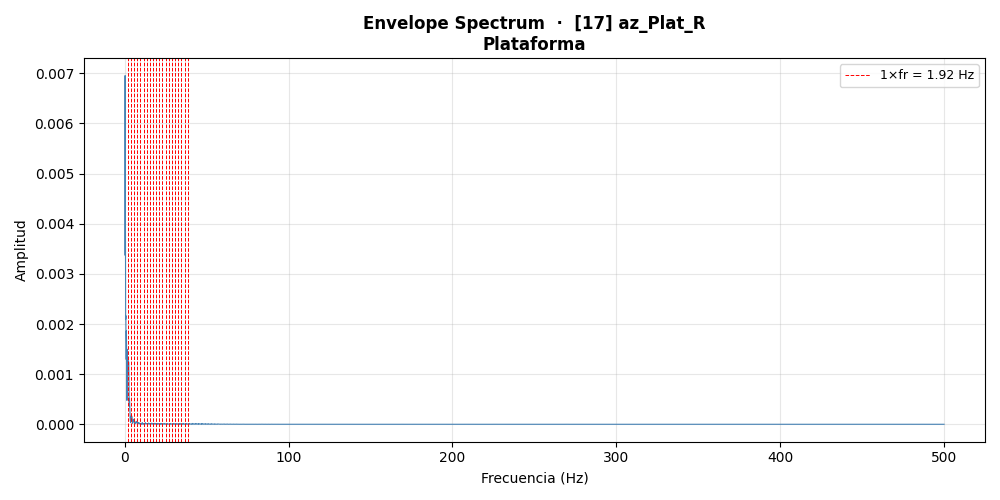

In [25]:
# ── Elige el índice del sensor (0 = primer sensor de la lista completa) ──────
SENSOR_IDX = 17          # <── cambia este número
FR = 1.92               # frecuencia de rotación (Hz)  <── ajusta si es necesario

# ─────────────────────────────────────────────────────────────────────────────
# Construir lista plana con (columna, grupo) para poder indexar fácilmente
sensores = [(col, grupo)
            for grupo, columnas in grupos.items()
            for col in columnas]

col, grupo = sensores[SENSOR_IDX]
print(f"[{SENSOR_IDX}] {col}  →  {grupo}")

# Envelope spectrum
señal  = df[col].values - df[col].mean()
env    = np.abs(signal.hilbert(señal))
env   -= env.mean()

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))

freqs_env, mag_env = ax.magnitude_spectrum(env, Fs=fs, color='steelblue', linewidth=0.8)[:2]

for i in range(1, 21):
    ax.axvline(x=i * FR, color='red', linestyle='--', linewidth=0.7,
               label=f'1×fr = {FR} Hz' if i == 1 else None)

ax.set_title(f"Envelope Spectrum  ·  [{SENSOR_IDX}] {col}\n{grupo}",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Amplitud")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()